
Step size h = 0.01
x		Error
0.0000	0.000000
0.0100	0.000000
0.0200	0.000000
0.0300	0.000000
0.0400	0.000000
0.0500	0.000000
0.0600	0.000000
0.0700	0.000000
0.0800	0.000000
0.0900	0.000000
0.1000	0.000000
0.1100	0.000000
0.1200	0.000000
0.1300	0.000000
0.1400	0.000000
0.1500	0.000000
0.1600	0.000000
0.1700	0.000000
0.1800	0.000000
0.1900	0.000000
0.2000	0.000000
0.2100	0.000000
0.2200	0.000000
0.2300	0.000000
0.2400	0.000000
0.2500	0.000000
0.2600	0.000000
0.2700	0.000000
0.2800	0.000000
0.2900	0.000000
0.3000	0.000000
0.3100	0.000000
0.3200	0.000000
0.3300	0.000000
0.3400	0.000000
0.3500	0.000000
0.3600	0.000000
0.3700	0.000000
0.3800	0.000000
0.3900	0.000000
0.4000	0.000000
0.4100	0.000000
0.4200	0.000000
0.4300	0.000000
0.4400	0.000000
0.4500	0.000000
0.4600	0.000000
0.4700	0.000000
0.4800	0.000000
0.4900	0.000000
0.5000	0.000000
0.5100	0.000000
0.5200	0.000000
0.5300	0.000000
0.5400	0.000000
0.5500	0.000000
0.5600	0.000000
0.5700	0.000000
0.5800	0.000000
0.5900	0.000000
0.6000	0.00

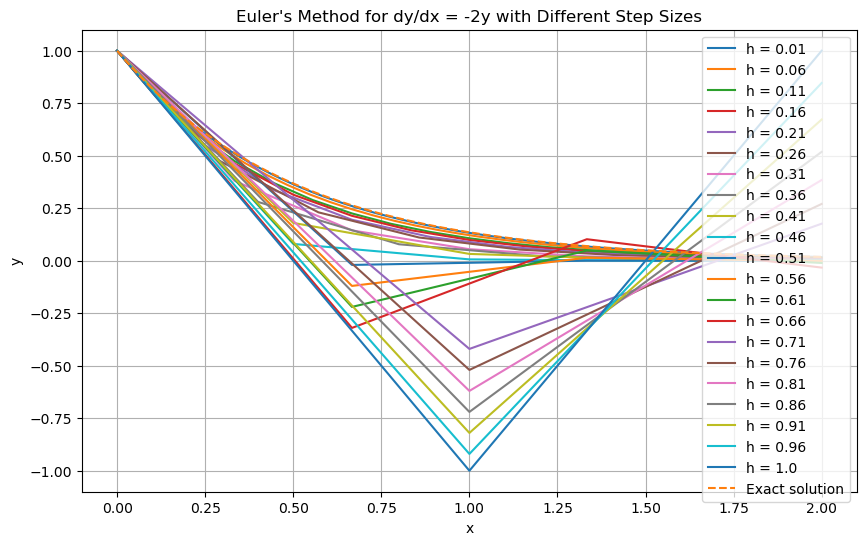

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ChatGPT was used to help organize and check this code.

def euler_method(h):
    x_start = 0
    x_end = 2
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    y_values[0] = 1  # y(0) = 1

    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * (-2 * y_values[i])

    return x_values, y_values

# Step sizes from 0.01 to 1.00 in steps of 0.05
h_values = list(np.round(np.arange(0.01, 1.00, 0.05), 2))
if 1.00 not in h_values:
    h_values.append(1.00)

# First run will be the reference run
x_ref, y_ref = euler_method(h_values[0])

plt.figure(figsize=(10, 6))

for h in h_values:
    x_vals, y_vals = euler_method(h)

    # Compare current run to first run using interpolation
    y_ref_interp = np.interp(x_vals, x_ref, y_ref)
    error = np.abs(y_vals - y_ref_interp)
    total_error = np.sum(error)

    print(f"\nStep size h = {h}")
    print("x\t\tError")
    for i in range(len(x_vals)):
        print(f"{x_vals[i]:.4f}\t{error[i]:.6f}")

    print(f"Total accumulated error for h = {h}: {total_error:.6f}")

    plt.plot(x_vals, y_vals, label=f"h = {h}")

# Exact solution for comparison
x_exact = np.linspace(0, 2, 400)
y_exact = np.exp(-2 * x_exact)
plt.plot(x_exact, y_exact, '--', label='Exact solution')

plt.xlabel('x')
plt.ylabel('y')
plt.title("Euler's Method for dy/dx = -2y with Different Step Sizes")
plt.legend()
plt.grid(True)
plt.show()